# Задача № 1. iPhone или Android: метод k ближайших соседей

Метод — **k ближайших соседей** (k-NN). Для новой анкеты модель находит k самых похожих респондентов из обучающей выборки и выбирает тот класс, который среди них встречается чаще.

Ноутбук закрывает пункты задания:

1. подготовка исходных данных;
2. разведочный анализ данных (EDA);
3. обучение и тестирование;
4. анализ, какое k лучше;
5. показ решения: метрики, матрица ошибок и соседи конкретного прогноза.


## 1. Импорт и загрузка данных

In [88]:
import os
# Убираем warning joblib про физические ядра на Windows
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# Настройки графиков
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Версия pandas: {pd.__version__}, numpy: {np.__version__}")

def resolve_data_path() -> Path:
    """Ищем CSV рядом с ноутбуком. Если нет — понятная ошибка."""
    path = Path("iphone_android.csv")
    if not path.exists():
        raise FileNotFoundError(
            f"Не найден файл {path.name}. Положите CSV рядом с ноутбуком."
        )
    return path

DATA_PATH = resolve_data_path()
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig", dtype=str)
df.columns = [
    "time",
    "stability",
    "photo",
    "blog",
    "overpay",
    "status_tech",
    "vpn",
    "age",
    "budget",
    "custom_ui",
    "ringtone",
    "resale",
    "custom_system",
    "change_years",
    "os_support",
    "job",
    "gender",
    "instagram",
    "charges",
    "money_habit",
    "headset",
    "apples",
    "phone",
]
print(f"Файл: {DATA_PATH.resolve()}")
print(f"Анкет: {len(df)}, столбцов: {df.shape[1]}")
df.head()


Версия pandas: 2.2.3, numpy: 1.26.4
Файл: /Users/kziborova/iphone_android.csv
Анкет: 41, столбцов: 23


,time,stability,photo,blog,overpay,status_tech,vpn,age,budget,custom_ui,...,change_years,os_support,job,gender,instagram,charges,money_habit,headset,apples,phone
0,2026/09/14 8:05:47 PM GMT+3,Стабильность,Раз в неделю,Нет,Экосистема;Надежность,Технологичность,VPN,21,80000,5,...,3,Не важна,IT,М,Нет,1,Экономить и откладывать,От одного бренда,1,Андроид
1,2026/09/14 8:05:56 PM GMT+3,Стабильность,Каждый день,Да,Статус;Камера,Статус,VPN,21,90000,6,...,3,Важна,Продажи,М,Да,5,Экономить и откладывать,От одного бренда,7,Айфон
2,2026/09/14 8:06:41 PM GMT+3,Новшество,Раз в неделю,Нет,Экосистема;Надежность;Мультивыбор,Статус,VPN,22,60,5,...,3,Важна,Менеджер,М,Нет,2,Порадовать себя,От одного бренда,4,Айфон
3,2026/09/14 8:07:06 PM GMT+3,Стабильность,Раз в месяц,Нет,Надежность,Технологичность,VPN,22,50000,1,...,7,Не важна,Студент,М,Нет,1,Экономить и откладывать,От разных брендов,10,Айфон
4,2026/09/14 8:07:09 PM GMT+3,Стабильность,Раз в неделю,Нет,Камера;Экосистема;Надежность,Технологичность,VPN,22,30000,3,...,2.5,Важна,Тех под,М,Нет,2,Экономить и откладывать,От разных брендов,1,Андроид


In [34]:
print("Пропуски:", int(df.isna().sum().sum()))
print("\nЦелевой класс:")
print(df["phone"].value_counts())
print("\nЧисловые поля до очистки:")
print(df[["age", "budget", "change_years", "charges", "custom_ui", "apples"]].head(8).to_string())


Пропуски: 0

Целевой класс:
phone
Андроид    22
Айфон      19
Name: count, dtype: int64

Числовые поля до очистки:
  age budget change_years charges custom_ui apples
0  21  80000            3       1         5      1
1  21  90000            3       5         6      7
2  22     60            3       2         5      4
3  22  50000            7       1         1     10
4  22  30000          2.5       2         3      1
5  22  70000            5       3         6     10
6  30  50000            4       2         7      2
7  21  70000            5       4         4      6


## 2. Подготовка исходных данных

Что исправляем в этой выгрузке:

- бюджет записан по-разному: `70000`, `100.000` (точка как разделитель тысяч), `60` и `120` (скорее всего тысячи рублей), одно значение `3` — ошибка ввода;
- возраст `5` не похож на ответ этой аудитории;
- вопрос «за что готовы переплатить» — несколько вариантов через `;`;
- сфера деятельности — свободный текст, почти у каждой анкеты своя формулировка. Оставляем четыре группы: IT, студент, бизнес, другое;
- порядковые ответы (как часто фотографирует, может ли поставить рингтон) кодируем числами, а не как несвязанные категории.

Метку времени удаляем.


### Очистка: бюджет и возраст

In [36]:
def parse_budget_token(value):
    text = str(value).strip().replace(" ", "").replace("\u00a0", "")
    if re.fullmatch(r"\d{1,3}\.\d{3}", text):
        text = text.replace(".", "")
    return float(text.replace(",", "."))

def plural(n, one, few, many):
    n = int(n)
    if n % 10 == 1 and n % 100 != 11:
        return one
    if 2 <= n % 10 <= 4 and not (12 <= n % 100 <= 14):
        return few
    return many
    
raw_budget = df["budget"].map(parse_budget_token)
budget = raw_budget.copy()
as_thousands = (budget >= 20) & (budget < 1000)
budget.loc[as_thousands] = budget.loc[as_thousands] * 1000
plausible = budget >= 1000
budget_median = float(budget.loc[plausible].median())
budget.loc[~plausible] = budget_median
df["budget"] = budget

age = pd.to_numeric(df["age"], errors="coerce")
plausible_age = age.where((age >= 16) & (age <= 80))
age_median = float(plausible_age.median())
df["age"] = plausible_age.fillna(age_median)

for column in ["change_years", "charges", "custom_ui", "apples"]:
    numeric = pd.to_numeric(
        df[column].astype(str).str.strip().str.replace(",", ".", regex=False),
        errors="coerce",
    )
    df[column] = numeric.fillna(float(numeric.median()))

n_thousands = int(as_thousands.sum())
n_bad_budget = int((~plausible).sum())
n_bad_age = int(plausible_age.isna().sum())

print(
    f"Бюджет: {n_thousands} "
    f"{plural(n_thousands, 'ответ', 'ответа', 'ответов')} в тысячах умножены на 1000."
)
print(
    f"Бюджет: {n_bad_budget} "
    f"{plural(n_bad_budget, 'неправдоподобное значение', 'неправдоподобных значения', 'неправдоподобных значений')} "
    f"заменены медианой {budget_median:.0f}."
)
print(
    f"Возраст: {n_bad_age} "
    f"{plural(n_bad_age, 'значение', 'значения', 'значений')} "
    f"заменены медианой {age_median:.0f}."
)
print(df[["age", "budget", "change_years"]].describe().round(1))

Бюджет: 4 ответа в тысячах умножены на 1000.
Бюджет: 1 неправдоподобное значение заменены медианой 60000.
Возраст: 1 значение заменены медианой 22.
        age    budget  change_years
count  41.0      41.0          41.0
mean   22.1   63536.6           4.0
std     2.4   26297.4           1.5
min    20.0   20000.0           1.0
25%    21.0   50000.0           3.0
50%    22.0   60000.0           4.0
75%    22.0   80000.0           5.0
max    34.0  120000.0           7.0


### Признаки: кодирование ответов анкеты

In [39]:
YES_NO = {"Да": 1.0, "Не знаю": 0.5, "Нет": 0.0}
PHOTO = {"Раз в месяц": 1.0, "Раз в неделю": 2.0, "Каждый день": 3.0}
OVERPAY_OPTIONS = ["Статус", "Камера", "Экосистема", "Надежность"]


def require_map(series, mapping, name):
    unknown = sorted(set(series.dropna().astype(str)) - set(mapping))
    if unknown:
        raise ValueError(f"Неизвестные ответы в «{name}»: {unknown}")
    return series.map(mapping)


def job_group(value):
    text = str(value).strip().casefold()
    if any(word in text for word in ["it", "ит", "програм", "разработ", "инженер", "корпоратив", "тех под"]):
        return "IT"
    if "студент" in text:
        return "Студент"
    if any(word in text for word in ["бизнес", "продаж", "предприним", "менеджер", "бар"]):
        return "Бизнес"
    return "Другое"


def overpay_flags(value):
    tokens = {token.strip() for token in str(value).split(";") if token.strip()}
    return {option: int(option in tokens) for option in OVERPAY_OPTIONS}


flags = df["overpay"].apply(overpay_flags).apply(pd.Series).add_prefix("overpay_")
job = df["job"].map(job_group)

X = pd.DataFrame(
    {
        "age": df["age"],
        "budget": df["budget"],
        "custom_ui": df["custom_ui"],
        "change_years": df["change_years"],
        "charges": df["charges"],
        "apples": df["apples"],
        "photo": require_map(df["photo"], PHOTO, "фото"),
        "ringtone": require_map(df["ringtone"], YES_NO, "рингтон"),
        "custom_system": require_map(df["custom_system"], YES_NO, "настройка системы"),
        "novelty": (df["stability"].str.strip() == "Новшество").astype(float),
        "blog": require_map(df["blog"], {"Да": 1.0, "Нет": 0.0}, "блог"),
        "status": (df["status_tech"].str.strip() == "Статус").astype(float),
        "vpn": (df["vpn"].str.strip() == "VPN").astype(float),
        "resale_ok": (df["resale"].str.strip() == "Хорошо").astype(float),
        "os_support": (df["os_support"].str.strip() == "Важна").astype(float),
        "male": (df["gender"].str.strip() == "М").astype(float),
        "instagram": require_map(df["instagram"], {"Да": 1.0, "Нет": 0.0}, "инстаграм"),
        "treat_yourself": (df["money_habit"].str.strip() == "Порадовать себя").astype(float),
        "one_brand": (df["headset"].str.strip() == "От одного бренда").astype(float),
        "job_it": (job == "IT").astype(float),
        "job_student": (job == "Студент").astype(float),
        "job_business": (job == "Бизнес").astype(float),
    }
)
X = pd.concat([X, flags], axis=1)
y = df["phone"].str.strip()

if set(y.unique()) != {"Айфон", "Андроид"}:
    raise ValueError(f"Неожиданные метки: {sorted(y.unique())}")
if X.isna().any().any():
    raise ValueError("После кодирования остались пропуски.")

print(f"Признаков: {X.shape[1]}")
print("Группы сферы деятельности:")
print(job.value_counts().to_string())
X.head()


Признаков: 26
Группы сферы деятельности:
job
IT         25
Другое      7
Бизнес      5
Студент     4


,age,budget,custom_ui,change_years,charges,apples,photo,ringtone,custom_system,novelty,...,instagram,treat_yourself,one_brand,job_it,job_student,job_business,overpay_Статус,overpay_Камера,overpay_Экосистема,overpay_Надежность
0,21.0,80000.0,5,3.0,1.0,1,2.0,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0,0,1,1
1,21.0,90000.0,6,3.0,5.0,7,3.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1,1,0,0
2,22.0,60000.0,5,3.0,2.0,4,2.0,0.5,1.0,1.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0,0,1,1
3,22.0,50000.0,1,7.0,1.0,10,1.0,0.5,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0,1
4,22.0,30000.0,3,2.5,2.0,1,2.0,0.5,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0,1,1,1


### Контроль качества после очистки 

In [46]:
assert df["budget"].between(1000, 500000).all(), "Есть подозрительный бюджет"
assert df["age"].between(16, 80).all(), "Есть подозрительный возраст"
assert X.isna().sum().sum() == 0, f"Остались пропуски: {X.isna().sum()[X.isna().sum() > 0]}"
assert set(y.unique()) == {"Айфон", "Андроид"}, f"Неожиданные классы: {y.unique()}"

print("Бюджет в диапазоне 1 000 – 500 000")
print("Возраст в диапазоне 16 – 80")
print("Пропусков нет")
print("Классы только Айфон / Андроид")
print(f"Итог: {len(X)} анкет, {X.shape[1]} признаков")

Бюджет в диапазоне 1 000 – 500 000
Возраст в диапазоне 16 – 80
Пропусков нет
Классы только Айфон / Андроид
Итог: 41 анкет, 26 признаков


## 3. EDA - разведочный анализ данных

Прежде чем строить модель, смотрим на данные глазами:
- нет ли перекоса классов (если 90% одного класса, модель может просто угадывать большинство);
- какие признаки различают Айфон и Андроид;
- нет ли выбросов, которые тянут расстояния в k-NN.

Шесть графиков:
1. Баланс классов.
2. Бюджет: Айфон vs Андроид.
3. Возраст: Айфон vs Андроид.
4. «Статус или технологичность» по платформам.
5. Сфера деятельности по платформам.
6. Корреляции числовых признаков с целевой.

#### EDA: баланс классов, бюджет, возраст

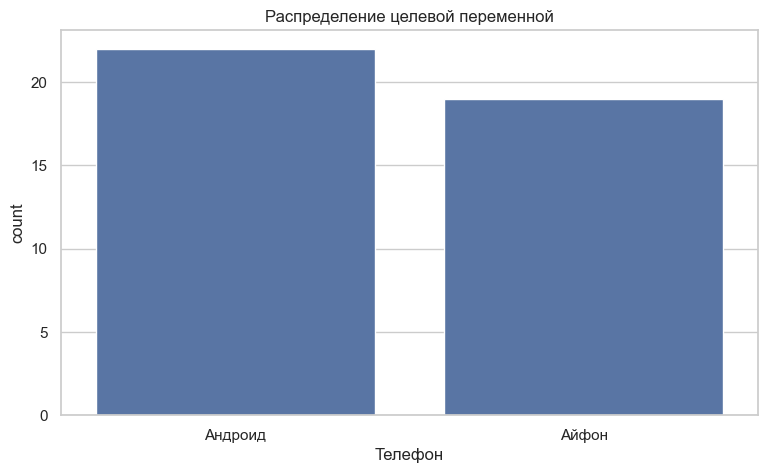

Доли классов:
phone
Андроид    0.537
Айфон      0.463
Name: proportion, dtype: float64


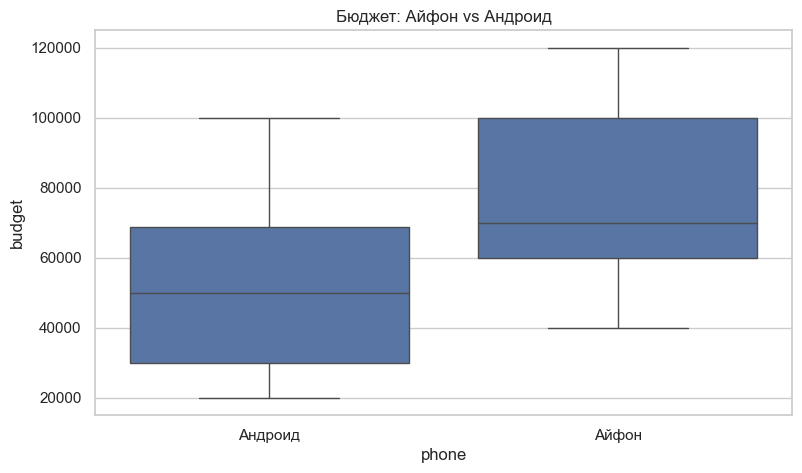

         count     mean      std      min      25%      50%       75%  \
phone                                                                   
Айфон     19.0  76842.0  22865.0  40000.0  60000.0  70000.0  100000.0   
Андроид   22.0  52045.0  23888.0  20000.0  30000.0  50000.0   68750.0   

              max  
phone              
Айфон    120000.0  
Андроид  100000.0  


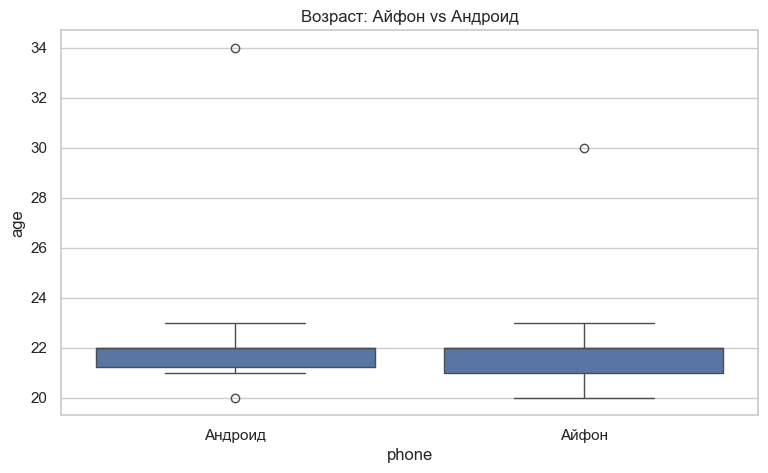

phone
Айфон      22.00
Андроид    22.27
Name: age, dtype: float64


In [51]:
# 1. Баланс классов
sns.countplot(x=y)
plt.title("Распределение целевой переменной")
plt.xlabel("Телефон")
plt.show()
print("Доли классов:")
print(y.value_counts(normalize=True).round(3))

# 2. Бюджет
plot_df = X.copy()
plot_df["phone"] = y.values
sns.boxplot(x="phone", y="budget", data=plot_df)
plt.title("Бюджет: Айфон vs Андроид")
plt.show()
print(plot_df.groupby("phone")["budget"].describe().round(0))

# 3. Возраст 
sns.boxplot(x="phone", y="age", data=plot_df)
plt.title("Возраст: Айфон vs Андроид")
plt.show()
print(plot_df.groupby("phone")["age"].mean().round(2))

#### EDA: статус, сфера деятельности, корреляции

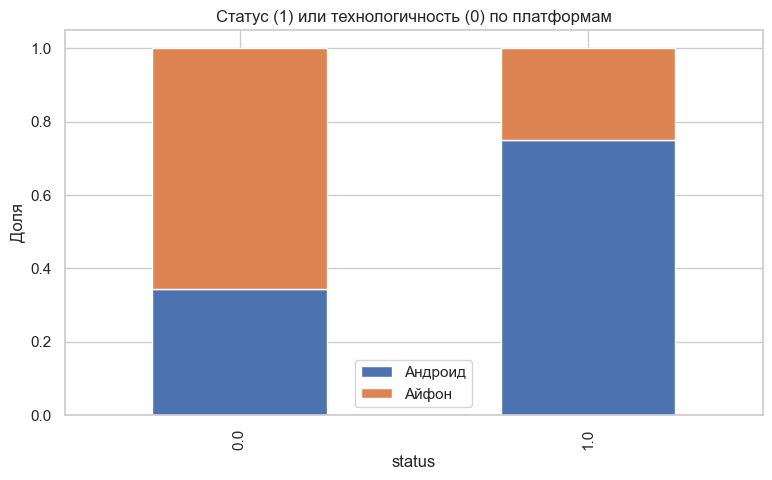

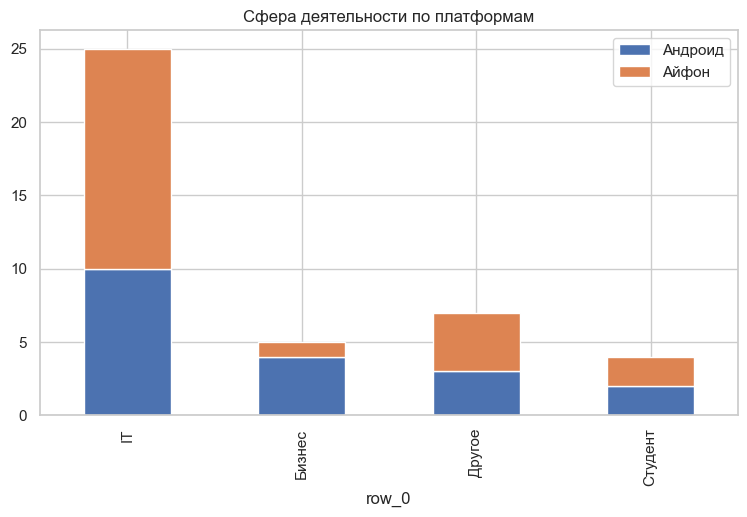

Топ-10 признаков по |корреляции| с Айфоном:
(положительная — тянет к Айфону, отрицательная — к Андроиду)
one_brand         0.558
budget            0.476
status            0.370
custom_ui        -0.340
treat_yourself    0.310
change_years     -0.266
charges           0.247
ringtone         -0.242
resale_ok         0.232
custom_system    -0.227
Name: target, dtype: float64


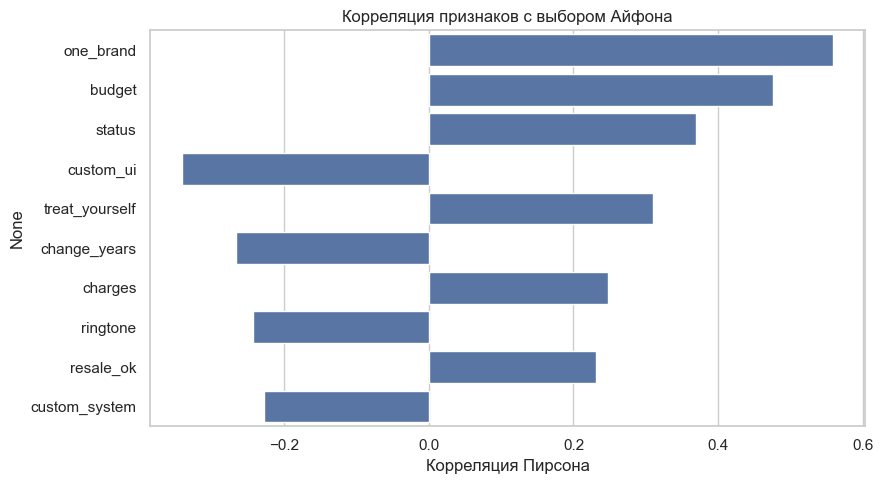

In [57]:
# 4. Статус или технологичность 
pd.crosstab(X["status"], y, normalize="index").plot(kind="bar", stacked=True)
plt.title("Статус (1) или технологичность (0) по платформам")
plt.ylabel("Доля")
plt.legend(["Андроид", "Айфон"] if y.iloc[0] == "Андроид" else ["Айфон", "Андроид"])
plt.show()

# 5. Сфера деятельности 
job_series = pd.Series(
    np.select(
        [X["job_it"] == 1, X["job_student"] == 1, X["job_business"] == 1],
        ["IT", "Студент", "Бизнес"],
        default="Другое",
    ),
    index=X.index,
)
pd.crosstab(job_series, y).plot(kind="bar", stacked=True)
plt.title("Сфера деятельности по платформам")
plt.legend(["Андроид", "Айфон"] if y.iloc[0] == "Андроид" else ["Айфон", "Андроид"])
plt.show()

# 6. Корреляции с целевой
numeric_cols = [
    "age", "budget", "custom_ui", "change_years", "charges", "apples",
    "photo", "ringtone", "custom_system", "novelty", "blog",
    "status", "vpn", "resale_ok", "os_support", "male", "instagram",
    "treat_yourself", "one_brand",
]
corr_target = (
    X[numeric_cols]
    .assign(target=(y == "Айфон").astype(int))
    .corr()["target"]
    .drop("target")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("Топ-10 признаков по |корреляции| с Айфоном:")
print("(положительная — тянет к Айфону, отрицательная — к Андроиду)")
print(corr_target.head(10).round(3))

sns.barplot(x=corr_target.head(10).values, y=corr_target.head(10).index)
plt.title("Корреляция признаков с выбором Айфона")
plt.xlabel("Корреляция Пирсона")
plt.tight_layout()
plt.show()

## 4. Профиль Айфон vs Андроид

Сводим средние значения признаков по двум группам и смотрим, где разница наибольшая. Это не модель, а способ понять, какие признаки вообще информативны.


In [97]:
profile = X.copy()
profile["phone"] = y.values
means = profile.groupby("phone").mean().T
means["разница Айфон − Андроид"] = means.get("Айфон", 0) - means.get("Андроид", 0)
means.round(2).sort_values(
    "разница Айфон − Андроид", key=lambda s: s.abs(), ascending=False
).head(12)

phone,Айфон,Андроид,разница Айфон − Андроид
budget,76842.11,52045.45,24796.65
custom_ui,4.58,5.95,-1.38
change_years,3.55,4.34,-0.79
apples,5.47,4.77,0.70
one_brand,0.74,0.18,0.56
charges,2.16,1.61,0.54
overpay_Камера,0.74,0.27,0.46
overpay_Статус,0.47,0.09,0.38
status,0.47,0.14,0.34
treat_yourself,0.58,0.27,0.31


#### Зачем нормировать признаки

k-NN сравнивает анкеты евклидовым расстоянием. Бюджет измеряется десятками тысяч рублей, оценка кастомизации — баллами от 1 до 10. Без нормировки бюджет перекроет остальные ответы, и «соседями» станут люди с похожей суммой, а не с похожими привычками.

StandardScaler вычитает среднее и делит на стандартное отклонение. Его нужно обучать только на обучающих строках. В кросс-валидации это делает Pipeline: на каждом фолде scaler заново считается по обучающей части фолда.

## 5. Какое k лучше

Выборка маленькая, поэтому одно разбиение на тест из ~10 анкет сильно скачет. k выбираем на **обучающей** части повторяющейся стратифицированной кросс-валидацией: 5 фолдов, 10 повторов. Тестовые анкеты в этот выбор не входят.

Смотрим среднюю accuracy и её разброс. Отдельно считаем accuracy на всей обучающей выборке: при k = 1 она обычно равна 1, потому что ближайший сосед строки — она сама. 

Для двух классов нечётное k не даёт ничьей поровну. Чётное k тоже можно оставить: если голоса соседей разделились, реализация sklearn всё равно возвращает один класс. Какой вариант сильнее, видно по таблице accuracy, а не по чётности.


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)
print(f"Обучение: {len(y_train)}, тест: {len(y_test)}")
print("Классы в обучении:")
print(y_train.value_counts().to_string())


def make_model(k):
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k, metric="euclidean")),
        ]
    )


ks = list(range(1, 16))
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
rows = []
for k in ks:
    model = make_model(k)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    model.fit(X_train, y_train)
    rows.append(
        {
            "k": k,
            "cv_accuracy": scores.mean(),
            "cv_std": scores.std(),
            "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        }
    )
results = pd.DataFrame(rows)

# Правило выбора:
# 1) максимум средней accuracy на кросс-валидации;
# 2) при разнице <= 0.01 предпочитаем меньшее k (проще и интерпретируемее);
# 3) при равенстве accuracy берём меньший std.
EPS = 0.01
top_acc = results["cv_accuracy"].max()
candidates = results[results["cv_accuracy"] >= top_acc - EPS]
best_row = candidates.sort_values(["k", "cv_std"]).iloc[0]
best_k = int(best_row["k"])
results.round(3)


Обучение: 30, тест: 11
Классы в обучении:
phone
Андроид    16
Айфон      14


,k,cv_accuracy,cv_std,train_accuracy
0,1,0.580,0.138,1.000
1,2,0.643,0.167,0.800
2,3,0.633,0.160,0.800
3,4,0.687,0.175,0.767
4,5,0.690,0.173,0.733
5,6,0.717,0.174,0.767
6,7,0.700,0.191,0.733
7,8,0.747,0.189,0.767
8,9,0.707,0.184,0.667
9,10,0.737,0.183,0.767


#### График точности от k

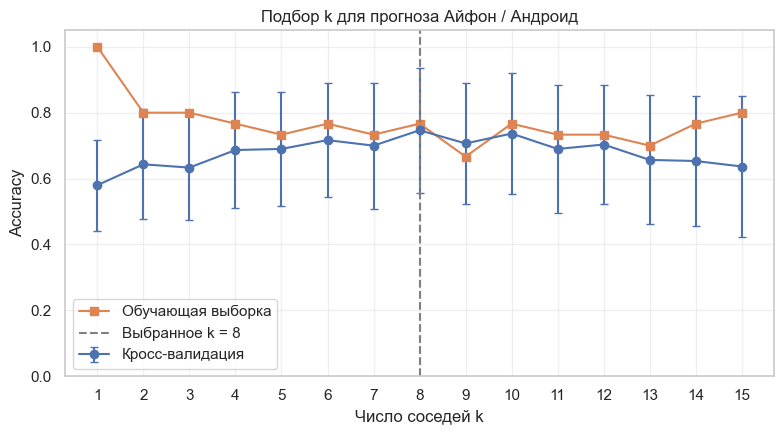

Три лучших k по кросс-валидации:
 k  cv_accuracy  cv_std  train_accuracy
 8        0.747   0.189           0.767
10        0.737   0.183           0.767
 6        0.717   0.174           0.767
Выбрано k = 8: accuracy 0.747 ± 0.189
k = 1 на обучении: 1.000, на кросс-валидации: 0.580
Выбранное k чётное. При равенстве голосов sklearn всё равно выдаёт один класс. Соседние нечётные k можно сравнить по таблице выше.
Малое k подстраивается под отдельные анкеты. Большое k сглаживает границу и тянет прогноз к более частому классу.


In [74]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    results["k"],
    results["cv_accuracy"],
    yerr=results["cv_std"],
    marker="o",
    capsize=3,
    label="Кросс-валидация",
)
ax.plot(
    results["k"],
    results["train_accuracy"],
    marker="s",
    label="Обучающая выборка",
)
ax.axvline(best_k, color="gray", linestyle="--", label=f"Выбранное k = {best_k}")
ax.set_xlabel("Число соседей k")
ax.set_ylabel("Accuracy")
ax.set_xticks(ks)
ax.set_ylim(0, 1.05)
ax.set_title("Подбор k для прогноза Айфон / Андроид")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

k1 = results.loc[results["k"] == 1].iloc[0]
top3 = results.sort_values(["cv_accuracy", "cv_std"], ascending=[False, True]).head(3)
print("Три лучших k по кросс-валидации:")
print(top3.round(3).to_string(index=False))
print(f"Выбрано k = {best_k}: accuracy {best_row['cv_accuracy']:.3f} ± {best_row['cv_std']:.3f}")
print(f"k = 1 на обучении: {k1['train_accuracy']:.3f}, на кросс-валидации: {k1['cv_accuracy']:.3f}")
if best_k % 2 == 0:
    print(
        "Выбранное k чётное. При равенстве голосов sklearn всё равно выдаёт один класс. "
        "Соседние нечётные k можно сравнить по таблице выше."
    )
print(
    "Малое k подстраивается под отдельные анкеты. "
    "Большое k сглаживает границу и тянет прогноз к более частому классу."
)


#### Проверка стабильности выбора k

In [79]:
# Меняем random_state кросс-валидации и смотрим, какое k выбирается
chosen = []
for seed in [1, 7, 21, 42, 99]:
    cv_seed = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=seed)
    accs = {}
    for k in ks:
        scores = cross_val_score(make_model(k), X_train, y_train, cv=cv_seed, scoring="accuracy")
        accs[k] = scores.mean()
    top = max(accs.values())
    cands = [k for k, v in accs.items() if v >= top - 0.01]
    chosen.append(min(cands))

print("Выбранное k при разных seed:", chosen)
print(f"Мода: {pd.Series(chosen).mode().tolist()}")

Выбранное k при разных seed: [8, 6, 6, 8, 8]
Мода: [8]


## 6. Тестирование выбранной модели

Модель с найденным k один раз обучается на всей обучающей части и проверяется на отложенных анкетах. Для сравнения считаем константный прогноз: всегда выдавать класс, который чаще встречался в обучении.

Матрица ошибок читается так: строки — фактический телефон, столбцы — прогноз модели.


#### Обучение и метрики на тесте

k = 8
Accuracy на тесте: 0.909
Константный прогноз «всегда Андроид»: 0.545

              precision    recall  f1-score   support

       Айфон      1.000     0.800     0.889         5
     Андроид      0.857     1.000     0.923         6

    accuracy                          0.909        11
   macro avg      0.929     0.900     0.906        11
weighted avg      0.922     0.909     0.908        11



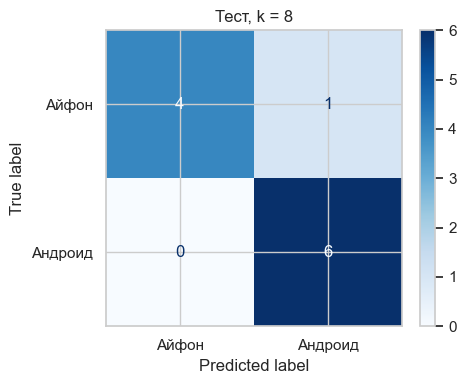

In [83]:
final_model = make_model(best_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
majority = y_train.mode().iloc[0]
baseline_accuracy = accuracy_score(y_test, np.full(len(y_test), majority))

print(f"k = {best_k}")
print(f"Accuracy на тесте: {test_accuracy:.3f}")
print(f"Константный прогноз «всегда {majority}»: {baseline_accuracy:.3f}")
print()
print(classification_report(y_test, y_pred, digits=3))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title(f"Тест, k = {best_k}")
plt.tight_layout()
plt.show()


#### Важность признаков

Топ-10 признаков по важности (permutation):
job_it            0.076
instagram         0.061
resale_ok         0.055
budget            0.055
charges           0.052
blog              0.048
treat_yourself    0.048
overpay_Камера    0.042
change_years      0.030
age               0.024
dtype: float64


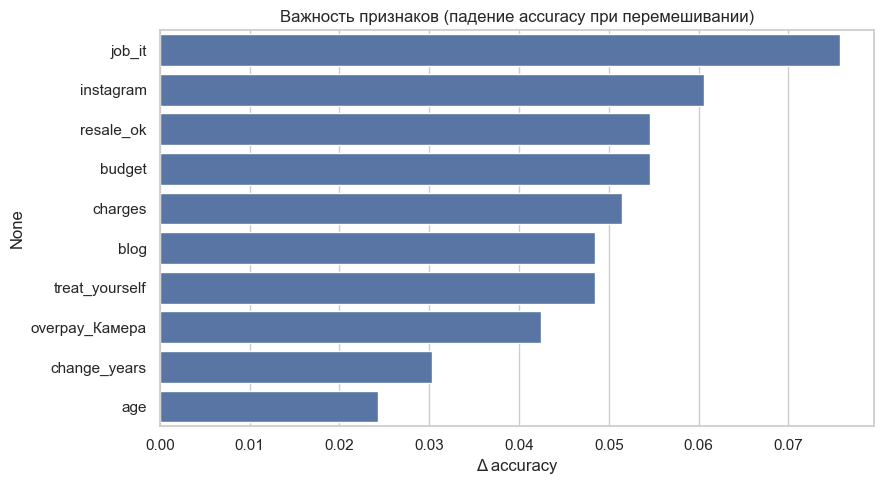

In [90]:
perm = permutation_importance(
    final_model, X_test, y_test,
    n_repeats=30, random_state=RANDOM_STATE, scoring="accuracy",
)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

print("Топ-10 признаков по важности (permutation):")
print(imp.head(10).round(3))

sns.barplot(x=imp.head(10).values, y=imp.head(10).index)
plt.title("Важность признаков (падение accuracy при перемешивании)")
plt.xlabel("Δ accuracy")
plt.tight_layout()
plt.show()

## 7. Как выглядит один прогноз

Для первой тестовой анкеты выводим k ближайших соседей из обучения: расстояние после нормировки и их реальный телефон. Класс прогноза — тот, которого среди этих соседей больше.


In [93]:
sample = X_test.iloc[[0]]
scaled = final_model.named_steps["scaler"].transform(sample)
distances, neighbor_pos = final_model.named_steps["knn"].kneighbors(scaled)

neighbor_table = pd.DataFrame(
    {
        "сосед": np.arange(1, best_k + 1),
        "расстояние": distances[0],
        "телефон соседа": y_train.to_numpy()[neighbor_pos[0]],
    }
)
print("Факт:", y_test.to_numpy()[0])
print("Прогноз:", y_pred[0])
neighbor_table.round(3)


Факт: Айфон
Прогноз: Андроид


,сосед,расстояние,телефон соседа
0,1,5.216,Андроид
1,2,5.398,Айфон
2,3,5.759,Айфон
3,4,5.779,Андроид
4,5,5.941,Андроид
5,6,6.051,Андроид
6,7,6.220,Айфон
7,8,6.255,Андроид


## 8. Вывод для обсуждения

**Данные и EDA:**
- Владельцы Айфона в среднем готовы потратить больше: медиана бюджета заметно выше.
- «Статус» чаще выбирают владельцы Айфона, «Технологичность» — владельцы Андроида.
- Сфера деятельности слабее различает классы, чем бюджет и отношение к статусу.
- Возраст почти не различается между группами.

**Выбор k:**
- k подбираем по повторяющейся кросс-валидации, а не по тесту и не по обучающей выборке.
- k = 1 даёт accuracy 1.000 на обучении и сильно ниже на CV — это запоминание, а не прогноз.
- Выбор k проверен на нескольких random_state — если он скачет, значит, данных мало для устойчивого решения.

**Финальную модель:**
- Accuracy на тесте заметно выше константного прогноза — модель выучила что-то осмысленное.
- Важность признаков (permutation) показывает, какие ответы реально влияют на прогноз.

**Ограничения:**
- 41 анкета — статистически мало. Разброс кросс-валидации большой.
- Один и тот же опрос заполнялся в одной аудитории, поэтому выборка не репрезентативна.
- Для уверенного выбора k нужен больший опрос.